# Were Barça's signings worth it? (2010/11 – 2025/26)

**Question:** for every player FC Barcelona paid a transfer fee for since 2010, was the fee justified by what he did *at Barça*, given his role?

**Approach, in one picture**

| Step | What | Why |
|---|---|---|
| 1 | **Football-inflation index** | €40m in 2010 ≠ €40m in 2025. All money is converted to 2025/26 football euros. |
| 2 | **Role-aware season scores** | Each La Liga season is scored against same-position peers (goals and assists matter for forwards, availability and goals conceded for defenders). |
| 3 | **Market model** (linear regression, ~7,600 La Liga player-seasons) | Learns what the market pays for a season of output → the *performance-implied value* (PIV) of each Barça season. |
| 4 | **Deal balance (headline)** | Performance value + money back (sale, loan fees, current value) − fee, with an 80% range. |
| 5 | **Fee test** | Fee vs fair fee (PIV × typical fee premium), from performance alone. |
| 6 | **Total-cost test** | Fee + wages − money back vs total value delivered, benchmarked across Barça's own signings (leave-one-out). |

Performance covers **La Liga plus the Champions League and Europa League**, with trophy points for competitions won. Two further questions: **was each fee reasonable at the moment of signing** (section 7c), and **how does Barça's record compare with Real Madrid's and Atlético's** (section 7d). Everything is run in three money bases (football index, consumer prices, actual euros) so you can see what the inflation adjustment does.

Data: [transfermarkt-datasets](https://github.com/dcaribou/transfermarkt-datasets) (snapshot to July 2026) + small hand-curated tables in `data/curated/`.


In [1]:
import sys, json
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from src.pipeline import run
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.color': '#e1e0d9', 'axes.edgecolor': '#c3c2b7',
                     'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e'})
BLUE, RED, GRAY, INK = '#2a78d6', '#e34948', '#898781', '#0b0b0b'
def short(name):
    last = name.split()[-1]
    return name if last in ('Suárez', 'Vidal', 'Jong', 'Torres') else last

d, summary, market_model, market_rows, ix, scored, results = run(verbose=False, use_cache=True)
from src.pipeline import MODELS
market_all = MODELS['football']
allclubs = pd.read_pickle('../data/processed/results_all_clubs.pkl')
summary

{'basis': 'football',
 'basis_label': "Today's football €",
 'market_model': {'n': 7607, 'r2': np.float64(0.671), 'sigma_log': 0.781},
 'market_model_all_leagues': {'n': 92543,
  'r2': np.float64(0.726),
  'sigma_log': 0.803},
 'market_premium': 1.25,
 'use_seasons': 5,
 'trophy_beta': 0.1521,
 'trophy_beta_se': 0.0337,
 'club_model': {'n': 59,
  'r2': np.float64(0.224),
  'intercept_m': np.float64(42.34),
  'slope': np.float64(0.188)},
 'n_signings': 59,
 'clubs': {'Barcelona': {'signings': 59,
   'spent_m': 3043.7,
   'recovered_m': 1710.5,
   'perf_value_m': 2525.9,
   'total_balance_m': 1192.7,
   'wages_m': 2769.4,
   'return_per_eur_total_cost': 0.729,
   'balance_per_eur': 0.392,
   'median_balance_m': 5.5,
   'good_share': 0.441,
   'bad_share': 0.203,
   'big_money': 16,
   'big_money_bad': 7,
   'decisions_rated': 59,
   'overpaid_at_signing_share': 0.068,
   'median_fee_to_fair_at_signing': 1.449,
   'median_fee_to_tm_value': 0.867},
  'Real Madrid': {'signings': 56,
   'spe

## 1. Football inflation

Three ways to put fees from different years on the same scale:

* **Football index (headline):** the average Transfermarkt value of the 200 most valuable top-5-league players each season, with 2025/26 = 1.0. It roughly tripled between 2010 and 2025.
* **Consumer prices:** euro-area HICP (`data/curated/euro_hicp.csv`, approximate). It rose only about 40% over the same period.
* **Actual euros:** no adjustment.

The dashed line is a fee-based index (mean of the top-100 fees). It tracks the football index from 2014, but the open dataset is missing many pre-2013 transfers, so it is biased low in the early years.

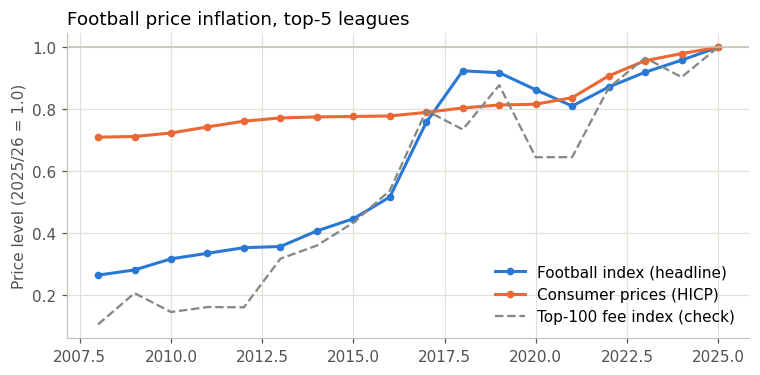

€1 in 2010: 3.16 football-€ today, 1.38 CPI-€ today
€1 in 2013: 2.81 football-€ today, 1.30 CPI-€ today
€1 in 2017: 1.32 football-€ today, 1.27 CPI-€ today


In [2]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(ix.season, ix['football_index'], color=BLUE, lw=2, marker='o', ms=4, label='Football index (headline)')
ax.plot(ix.season, ix['cpi_index'], color='#eb6834', lw=2, marker='o', ms=4, label='Consumer prices (HICP)')
ax.plot(ix.season, ix['fee_index'], color=GRAY, lw=1.5, ls='--', label='Top-100 fee index (check)')
ax.axhline(1, color='#c3c2b7', lw=1)
ax.set_ylabel('Price level (2025/26 = 1.0)'); ax.set_title('Football price inflation, top-5 leagues', loc='left')
ax.legend(frameon=False); plt.show()
i = ix.set_index('season')
for y in (2010, 2013, 2017):
    print(f"€1 in {y}: {1/i.loc[y,'football_index']:.2f} football-€ today, {1/i.loc[y,'cpi_index']:.2f} CPI-€ today")

## 2. The signings

59 paid signings. 45 come straight from the dataset; 15 (mostly 2010–2017 players whose later careers left the tracked leagues) come from `data/curated/missing_signings.csv`, including one multi-stage deal (Emerson Royal) merged into a single row. League appearance data starts in **2012/13**. Villa, Adriano, Mascherano, Afellay, Alexis and Fàbregas have their 2010–12 seasons credited at their covered-season average (`partial_data`).

In [3]:
d[['player','group','signing_season','from_club','fee_eur','fee_adj','seasons','seasons_covered','exit_to','ongoing','source']] \
  .assign(fee_eur=lambda x: x.fee_eur/1e6).round(1).sort_values('signing_season')

,player,group,signing_season,from_club,fee_eur,fee_adj,seasons,seasons_covered,exit_to,ongoing,source
0,David Villa,FW,2010,Valencia,40.0,126.4,3,1,Atlético Madrid,False,curated
1,Adriano,FB,2010,Sevilla,9.5,30.0,6,4,Beşiktaş,False,curated
2,Javier Mascherano,MID,2010,Liverpool,22.0,69.5,8,6,Hebei China Fortune,False,curated
3,Ibrahim Afellay,AM,2010,PSV Eindhoven,3.0,9.5,3,1,Stoke City,False,curated
4,Alexis Sánchez,FW,2011,Udinese,26.0,77.8,3,2,Arsenal,False,dataset
5,Cesc Fàbregas,MID,2011,Arsenal,34.0,101.7,3,2,Chelsea,False,curated
6,Jordi Alba,FB,2012,Valencia,14.0,39.7,11,11,Inter Miami,False,curated
7,Alex Song,MID,2012,Arsenal,19.0,53.9,2,2,Rubin Kazan,False,curated
8,Neymar,AM,2013,Santos,88.0,247.0,4,4,PSG,False,dataset
9,Claudio Bravo,GK,2014,Real Sociedad,12.0,29.5,3,3,Man City,False,dataset


## 3. Role-aware season scores

For each La Liga season, each metric is turned into a z-score **within the same role group and season**, using peers with 450+ minutes:

* `g90`, `a90`: goals and assists per 90
* `mins`: share of the team's league minutes (availability plus the coach's trust)
* `onoff`: team points per game with him (60+ min) minus without
* `cs`: goals the team concedes per game when he plays 60+ (fewer is better)

Per-90 z-scores shrink toward 0 when a player has few minutes. Weights by role are set in `src/config.py` → `ROLE_WEIGHTS`. Change them and re-run.

In [4]:
from src.config import ROLE_WEIGHTS
pd.DataFrame(ROLE_WEIGHTS).T

,g90,a90,mins,onoff,cs
GK,0.00,0.00,0.45,0.20,0.35
CB,0.05,0.00,0.40,0.25,0.30
FB,0.05,0.25,0.30,0.20,0.20
MID,0.15,0.25,0.35,0.25,0.00
AM,0.30,0.30,0.20,0.20,0.00
FW,0.45,0.20,0.20,0.15,0.00


In [5]:
b = scored[scored.club_id == 131]
b[b.season == 2015].sort_values('score', ascending=False)[['name','group','minutes','goals','assists','z_g90','z_a90','z_mins','z_onoff','z_cs','score']].round(2).head(15)

,name,group,minutes,goals,assists,z_g90,z_a90,z_mins,z_onoff,z_cs,score
13625,Luis Suárez,FW,3150,40,18,2.32,2.18,1.79,0.62,0.84,1.93
23158,Neymar,AM,3056,24,16,2.19,1.45,2.20,-0.40,0.79,1.45
7747,Lionel Messi,AM,2729,26,16,2.26,1.69,1.75,-0.79,0.78,1.38
23578,Jordi Alba,FB,2591,0,8,-0.38,1.55,1.12,0.03,1.10,0.93
12203,Claudio Bravo,GK,2878,0,0,0.00,-0.27,0.71,-0.33,1.12,0.64
9013,Ivan Rakitic,MID,2578,7,2,1.56,-0.18,0.97,0.05,0.93,0.54
4977,Gerard Piqué,CB,2591,2,1,0.29,0.24,1.05,-0.89,0.86,0.47
4093,Dani Alves,FB,2149,0,4,-0.36,0.64,0.53,-0.26,0.92,0.43
27535,Sergi Roberto,MID,1915,0,5,-0.56,1.11,0.11,0.10,0.78,0.26
22399,Sergio Busquets,MID,2909,0,4,-0.63,0.29,1.39,-1.08,0.73,0.19


## 4. The market model: what is a season of output worth?

A **linear regression** on every La Liga player-season 2012/13–2025/26:

`log(end-of-season market value, 2025/26 €) ~ role + role × (g90, a90, mins, onoff, cs z-scores) + age + age² + team points per game`
`    + role × (European g90, a90 z-scores) + European minutes z + in Champions League + in Europa League`

This is your original idea (predict transfer value from stats) at league scale. Using logs means coefficients act as percentages: `+0.5` ≈ ×1.65 value.

In [6]:
print(f"n = {int(market_model.nobs)},  R² = {market_model.rsquared:.3f},  residual SD (log) = {np.sqrt(market_model.scale):.3f}")
market_model.params.round(3).to_frame('coef')

n = 7607,  R² = 0.671,  residual SD (log) = 0.781


,coef
Intercept,6.715
C(group)[T.CB],-0.221
C(group)[T.FB],-0.356
C(group)[T.FW],0.160
C(group)[T.GK],-0.167
C(group)[T.MID],-0.074
C(group)[AM]:z_g90,0.280
C(group)[CB]:z_g90,0.086
C(group)[FB]:z_g90,0.104
C(group)[FW]:z_g90,0.261


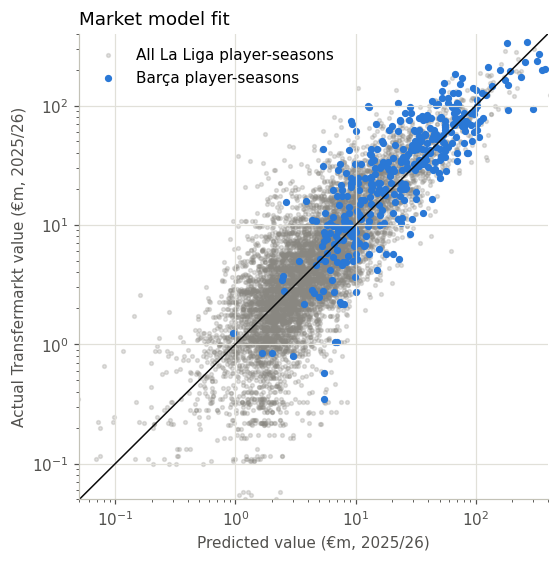

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
pred = np.exp(market_model.fittedvalues)/1e6; act = market_rows['mv_adj']/1e6
ax.scatter(pred, act, s=6, alpha=.25, color=GRAY, label='All La Liga player-seasons')
bb = market_rows.club_id == 131
ax.scatter(pred[bb], act[bb], s=14, color=BLUE, label='Barça player-seasons')
ax.set_xscale('log'); ax.set_yscale('log'); lim = [0.05, 400]
ax.plot(lim, lim, color=INK, lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Predicted value (€m, 2025/26)'); ax.set_ylabel('Actual Transfermarkt value (€m, 2025/26)')
ax.set_title('Market model fit', loc='left'); ax.legend(frameon=False, loc='upper left'); plt.show()

## 4b. European matches

Champions League and Europa League appearances are scored like the league: goals/90, assists/90 and share of team minutes, z-scored against **everyone in that competition in the same role** (peers need 270+ minutes). Europa League output is discounted by 0.6. Goalkeepers are judged on minutes only.

What the market model learns (football-€ basis):

In [8]:
eu = [k for k in market_model.params.index if k.startswith('eu_') or k in ('in_cl', 'in_el')]
pd.DataFrame({'coef': market_model.params[eu], 'x value': np.exp(market_model.params[eu]), 'p': market_model.pvalues[eu]}).round(3)

,coef,x value,p
eu_g90_CB,0.013,1.013,0.855
eu_a90_CB,-0.007,0.993,0.933
eu_g90_FB,0.067,1.069,0.377
eu_a90_FB,0.039,1.039,0.592
eu_g90_MID,0.043,1.044,0.535
eu_a90_MID,-0.030,0.971,0.654
eu_g90_AM,0.002,1.002,0.972
eu_a90_AM,-0.020,0.980,0.763
eu_g90_FW,-0.047,0.954,0.533
eu_a90_FW,0.136,1.146,0.100


How to read this: being at a **Champions League club** multiplies a player's value by about 2.6 compared with a non-European club at the same league output (the Europa League by about 1.7). Holding that constant, **individual European goals and assists add little**; European minutes add about 10% per standard deviation. For Barça signings, this mostly means every season is priced at Champions League level, while European output separates players only slightly. Adding Europe raised the model's R² from 0.64 to 0.67.

In [9]:
b = scored[scored.club_id == 131]
b[b.season == 2014].sort_values('eu_minutes', ascending=False)[['name','group','minutes','goals','eu_comps','eu_minutes','eu_goals','eu_assists','score','eu_score']].round(2).head(12)

,name,group,minutes,goals,eu_comps,eu_minutes,eu_goals,eu_assists,score,eu_score
7746,Lionel Messi,AM,3375,43,CL,1146.0,10.0,6.0,1.90,1.54
5318,Javier Mascherano,MID,2206,0,CL,1079.0,0.0,1.0,0.12,0.30
23157,Neymar,AM,2571,22,CL,1025.0,10.0,0.0,1.12,0.62
4976,Gerard Piqué,CB,2385,5,CL,990.0,1.0,0.0,0.77,0.49
23577,Jordi Alba,FB,2334,1,CL,962.0,0.0,2.0,0.47,0.39
4092,Dani Alves,FB,2524,0,CL,961.0,0.0,4.0,0.90,0.73
9012,Ivan Rakitic,MID,2033,5,CL,886.0,2.0,1.0,0.87,0.12
13624,Luis Suárez,FW,2179,16,CL,827.0,7.0,3.0,0.84,0.63
22398,Sergio Busquets,MID,2493,1,CL,788.0,0.0,0.0,0.10,-0.43
1992,Andrés Iniesta,MID,1590,0,CL,786.0,0.0,5.0,-0.33,0.33


## 4c. Trophy points

Goals, assists and minutes count extra in any competition the club **won**. For each won competition:

`involvement = 0.6 × share of team minutes + 0.4 × share of team goals+assists` (each capped at 1)
`trophy points = Σ weight × involvement`, with weights **Champions League 3, La Liga 2, Copa del Rey / Europa League 1, Club World Cup 0.75, Supercopa / UEFA Super Cup 0.5**

Winners come from the match data: most points for La Liga, and the final for cups (scores include shoot-outs; two-legged Supercopa finals use aggregate, then away goals). The market model then learns what one point is worth in euros.

In [10]:
from src.trophies import winners
from src.data import load
w = winners(); names = load('clubs').set_index('club_id')['name']
w[w.club_id == 131].assign(competition=lambda x: x.competition_id).groupby('season').competition.apply(', '.join).to_frame('Barça trophies')

,Barça trophies
season,
2012,ES1
2013,SUC
2014,"ES1, CDR, CL"
2015,"ES1, CDR, KLUB, USC"
2016,"CDR, SUC"
2017,"ES1, CDR"
2018,"ES1, SUC"
2020,CDR
2022,"ES1, SUC"


In [11]:
b = market_model.params['trophy_pts']; se = market_model.bse['trophy_pts']
print(f"Each trophy point multiplies a season's value by {np.exp(b):.3f} (±{1.96*se:.3f}, p={market_model.pvalues['trophy_pts']:.1e})")
print(f"A leading role in a treble (~3.5 points): ×{np.exp(3.5*b):.2f};  a regular in a title-only season (~1.3 points): ×{np.exp(1.3*b):.2f}")
scored[scored.club_id == 131].sort_values('trophy_pts', ascending=False)[['season','name','trophy_pts','trophies']].head(10)

Each trophy point multiplies a season's value by 1.164 (±0.066, p=6.5e-06)
A leading role in a treble (~3.5 points): ×1.70;  a regular in a title-only season (~1.3 points): ×1.22


,season,name,trophy_pts,trophies
7746,2014,Lionel Messi,4.537979,"Copa del Rey (51%), Champions League (79%), La..."
23157,2014,Neymar,3.558290,"Copa del Rey (47%), Champions League (65%), La..."
13624,2014,Luis Suárez,3.117652,"Copa del Rey (46%), Champions League (55%), La..."
13625,2015,Luis Suárez,2.929919,"Copa del Rey (33%), La Liga (76%), Club World ..."
5318,2014,Javier Mascherano,2.920065,"Copa del Rey (45%), Champions League (57%), La..."
4092,2014,Dani Alves,2.907649,"Copa del Rey (35%), Champions League (54%), La..."
4976,2014,Gerard Piqué,2.842919,"Copa del Rey (40%), Champions League (52%), La..."
23577,2014,Jordi Alba,2.808900,"Copa del Rey (40%), Champions League (52%), La..."
9012,2014,Ivan Rakitic,2.626170,"Copa del Rey (34%), Champions League (49%), La..."
7747,2015,Lionel Messi,2.471062,"Copa del Rey (52%), La Liga (63%), Club World ..."


## 5. Test 1: the fee test

**Fair fee = PIV × market premium**, where PIV is the model's value for each of the player's Barça seasons (geometric mean) and the premium is the median fee ÷ Transfermarkt value for €10m+ transfers into top-5-league clubs (≈1.25).

* **Overpaid**: fee above the 80% prediction interval of the fair fee
* **Bargain**: fee below it
* **Fair price**: inside it

The interval is wide (the model's residual SD is about 0.82 in logs), so a verdict of overpaid or bargain is a strong statement.

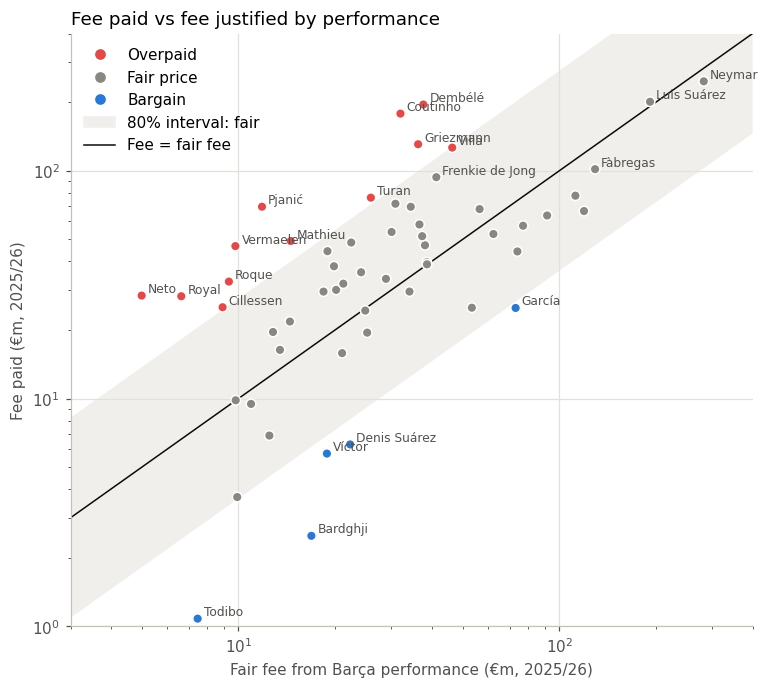

In [12]:
t = d.dropna(subset=['fair_fee_mean_eur']).copy()
for c in ['fair_fee_mean_eur','fair_fee_lo_eur','fair_fee_hi_eur']: t[c] = t[c]/1e6
col = t.market_verdict.map({'Overpaid': RED, 'Bargain': BLUE, 'Fair price': GRAY})
fig, ax = plt.subplots(figsize=(8, 7))
xs = np.logspace(0, 2.6, 50); k = np.exp(1.2816*np.sqrt(market_model.scale))
ax.fill_between(xs, xs/k, xs*k, color='#f0efec', label='80% interval: fair')
ax.plot(xs, xs, color=INK, lw=1, label='Fee = fair fee')
ax.scatter(t.fair_fee_mean_eur, t.fee_adj, c=col, s=40, edgecolor='white', lw=1, zorder=3)
for _, r in t.iterrows():
    if r.market_verdict != 'Fair price' or r.fee_adj > 90:
        ax.annotate(short(r.player), (r.fair_fee_mean_eur, r.fee_adj), fontsize=8, xytext=(4, 2), textcoords='offset points', color='#52514e')
ax.set_xscale('log'); ax.set_yscale('log'); ax.set_xlim(3, 400); ax.set_ylim(1, 400)
ax.set_xlabel('Fair fee from Barça performance (€m, 2025/26)'); ax.set_ylabel('Fee paid (€m, 2025/26)')
ax.set_title('Fee paid vs fee justified by performance', loc='left')
from matplotlib.lines import Line2D
h = [Line2D([], [], marker='o', ls='', color=c, label=l) for l, c in [('Overpaid', RED), ('Fair price', GRAY), ('Bargain', BLUE)]]
ax.legend(handles=h + ax.get_legend_handles_labels()[0], frameon=False, loc='upper left'); plt.show()

In [13]:
t[['player','signing_season','fee_adj','fair_fee_mean_eur','fair_fee_lo_eur','fair_fee_hi_eur','fee_to_fair','market_verdict']] \
  .sort_values('fee_to_fair', ascending=False).round(2)

,player,signing_season,fee_adj,fair_fee_mean_eur,fair_fee_lo_eur,fair_fee_hi_eur,fee_to_fair,market_verdict
46,Miralem Pjanić,2020,69.55,11.85,4.36,32.25,5.87,Overpaid
38,Neto,2019,28.33,5.00,1.84,13.60,5.67,Overpaid
29,Philippe Coutinho,2017,178.19,32.00,11.76,87.06,5.57,Overpaid
28,Ousmane Dembélé,2017,195.35,37.71,13.86,102.61,5.18,Overpaid
14,Thomas Vermaelen,2014,46.72,9.79,3.60,26.64,4.77,Overpaid
35,Emerson Royal,2018,28.14,6.64,2.44,18.07,4.24,Overpaid
39,Antoine Griezmann,2019,130.76,36.33,13.35,98.84,3.60,Overpaid
54,Vitor Roque,2023,32.63,9.35,3.44,25.43,3.49,Overpaid
13,Jérémy Mathieu,2014,49.17,14.57,5.36,39.65,3.37,Overpaid
17,Arda Turan,2015,76.21,25.88,9.51,70.42,2.94,Overpaid


## 5b. Deal balance (the headline)

**Balance = performance value + money back − fee**

* **Performance value:** each Barça season is credited with 1/5 of that season's fair fee, priced as if the player were 27. Age is left out here because a season's output is worth the same to Barça whatever his birth year. Age still matters through the money back: young players keep resale value, old ones don't.
* **Money back:** sale fee + loan fees received + current market value if he's still at the club.
* **Zero point:** paying exactly the fair fee, playing at that level for five seasons and leaving for free gives a balance of 0.
* **Verdict:** profit or loss only when the whole 80% range sits on one side of zero.

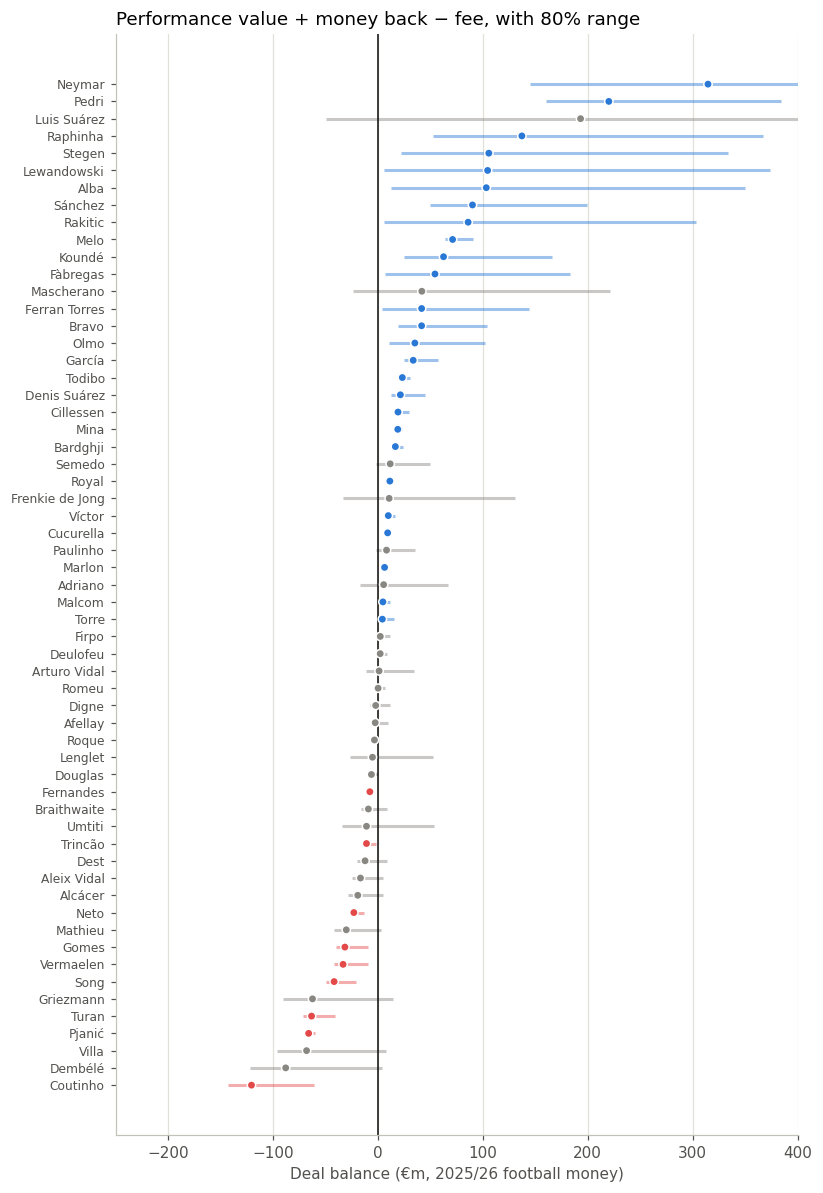

In [14]:
t = d.sort_values('balance_adj')
col = t.balance_verdict.map({'Loss': RED, 'Profit': BLUE, 'Break-even': GRAY})
fig, ax = plt.subplots(figsize=(8, 13))
y = np.arange(len(t))
ax.hlines(y, t.balance_lo.clip(-250, 400), t.balance_hi.clip(-250, 400), color=col, alpha=.45, lw=2)
ax.scatter(t.balance_adj, y, c=col, s=30, zorder=3, edgecolor='white')
ax.axvline(0, color=INK, lw=1); ax.set_yticks(y); ax.set_yticklabels([short(n) for n in t.player], fontsize=8)
ax.set_xlim(-250, 400); ax.set_xlabel('Deal balance (€m, 2025/26 football money)')
ax.set_title('Performance value + money back − fee, with 80% range', loc='left'); ax.grid(axis='y', visible=False); plt.show()

In [15]:
d[['player','signing_season','fee_adj','perf_value_adj','recovered_adj','balance_adj','balance_lo','balance_hi','balance_verdict','verdict']] \
  .sort_values('balance_adj', ascending=False).round(1)

,player,signing_season,fee_adj,perf_value_adj,recovered_adj,balance_adj,balance_lo,balance_hi,balance_verdict,verdict
8,Neymar,2013,247.0,268.6,293.0,314.6,144.8,776.8,Profit,Good deal
42,Pedri,2019,25.1,95.2,150.0,220.1,159.9,383.9,Profit,Good deal
12,Luis Suárez,2014,200.9,383.7,10.4,193.2,-49.5,853.4,Break-even,Fair deal
50,Raphinha,2022,66.6,133.8,70.0,137.2,52.6,367.5,Profit,Good deal
10,Marc-André ter Stegen,2014,29.5,132.3,3.0,105.7,22.1,333.3,Profit,Good deal
51,Robert Lewandowski,2022,51.6,156.2,0.0,104.6,5.8,373.5,Profit,Good deal
6,Jordi Alba,2012,39.7,143.0,0.0,103.3,12.9,349.4,Profit,Good deal
4,Alexis Sánchez,2011,77.8,63.4,104.5,90.2,50.1,199.3,Profit,Good deal (resale)
11,Ivan Rakitic,2014,44.3,126.2,4.1,86.0,6.2,303.2,Profit,Good deal
31,Arthur Melo,2018,33.6,11.3,93.4,71.2,64.0,90.7,Profit,Good deal (resale)


**How sensitive is this to the 5-season assumption?** Shorter payback periods (3 seasons) credit each season more; longer ones (7) credit it less.

In [16]:
from src.value import add_deal_balance
from src.market import market_premium
prem = market_premium(); rows = []
for n in (3, 5, 7):
    x = add_deal_balance(d, market_model, prem, use_seasons=n)
    rows.append(x.set_index('player')['balance_verdict'].rename(f'{n} seasons'))
sens = pd.concat(rows, axis=1)
print({c: sens[c].value_counts().to_dict() for c in sens})
sens[(sens.nunique(axis=1) > 1)]

{'3 seasons': {'Profit': 32, 'Break-even': 23, 'Loss': 4}, '5 seasons': {'Profit': 26, 'Break-even': 24, 'Loss': 9}, '7 seasons': {'Break-even': 21, 'Profit': 20, 'Loss': 18}}


,3 seasons,5 seasons,7 seasons
player,,,
David Villa,Break-even,Break-even,Loss
Javier Mascherano,Profit,Break-even,Break-even
Cesc Fàbregas,Profit,Profit,Break-even
Jordi Alba,Profit,Profit,Break-even
Alex Song,Break-even,Loss,Loss
Ivan Rakitic,Profit,Profit,Break-even
Luis Suárez,Profit,Break-even,Break-even
Jérémy Mathieu,Break-even,Break-even,Loss
Thomas Vermaelen,Break-even,Loss,Loss


## 6. Test 2: total cost of ownership, with wages

**Net total cost** = fee + wages over the Barça seasons − (sale fee + loan fees received + current market value if he's still at the club), all in 2025/26 €.
**Value delivered** = sum of the performance-implied values across his Barça seasons (in €m-seasons).

Regression across Barça's own signings: `net total cost ~ value delivered`. Each player is judged by a fit **without him** (leave-one-out), with an 80% prediction interval.

**Wages** come from Capology (`src/wages.py`). Actual player salaries are used where Capology lists them: Barça 2017/18, 2018/19 and 2020/21, and Real Madrid and Atlético 2026/27. Everywhere else, each club-season's gross fixed payroll is split across the squad in proportion to what a player of that market value and age typically earns, scaled by the player's own actual/estimated ratio when one is known. Seasons before 2013/14 reuse the 2013/14 payroll. This test is a **supporting check**, not the headline.

                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            42.3387     12.427      3.407      0.001      17.453      67.224
value_delivered_m     0.1877      0.046      4.053      0.000       0.095       0.280
R² = 0.224


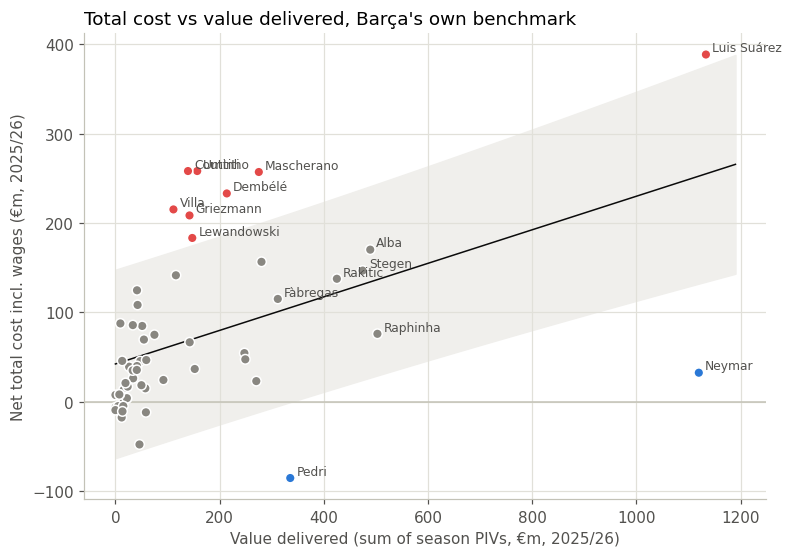

In [17]:
fit2 = smf.ols('net_total_cost_adj ~ value_delivered_m', data=d).fit()
print(fit2.summary().tables[1]); print('R² =', round(fit2.rsquared, 3))
col = d.net_total_cost_adj_verdict.map({'Overpaid': RED, 'Bargain': BLUE, 'Fair price': GRAY})
fig, ax = plt.subplots(figsize=(8, 5.5))
xs = np.linspace(0, d.value_delivered_m.max()*1.05, 50)
pr = fit2.get_prediction(pd.DataFrame({'value_delivered_m': xs})).summary_frame(alpha=.2)
ax.fill_between(xs, pr.obs_ci_lower, pr.obs_ci_upper, color='#f0efec'); ax.plot(xs, pr['mean'], color=INK, lw=1)
ax.scatter(d.value_delivered_m, d.net_total_cost_adj, c=col, s=40, edgecolor='white', lw=1, zorder=3)
for _, r in d.iterrows():
    if r.net_total_cost_adj_verdict != 'Fair price' or r.value_delivered_m > 300:
        ax.annotate(short(r.player), (r.value_delivered_m, r.net_total_cost_adj), fontsize=8, xytext=(4, 2), textcoords='offset points', color='#52514e')
ax.axhline(0, color='#c3c2b7', lw=1)
ax.set_xlabel('Value delivered (sum of season PIVs, €m, 2025/26)'); ax.set_ylabel('Net total cost incl. wages (€m, 2025/26)')
ax.set_title("Total cost vs value delivered, Barça's own benchmark", loc='left'); plt.show()

## 7. Headline verdicts

| Label | Meaning |
|---|---|
| Good deal / Bad deal | The deal balance's 80% range is entirely above / below zero |
| Good deal (resale) | Positive only because of the sale or current value; the football alone didn't cover the fee |
| … (all tests agree) | The fee test and the total-cost test point the same way |
| Leaning good / bad deal | The balance is inconclusive, but both other tests agree |
| Fair deal | Everything else |

In [18]:
cols = ['player','signing_season','fee_adj','balance_adj','balance_verdict','market_verdict','net_total_cost_adj_verdict','verdict','partial_data']
d[cols].sort_values('balance_adj', ascending=False).round(1)

,player,signing_season,fee_adj,balance_adj,balance_verdict,market_verdict,net_total_cost_adj_verdict,verdict,partial_data
8,Neymar,2013,247.0,314.6,Profit,Fair price,Bargain,Good deal,False
42,Pedri,2019,25.1,220.1,Profit,Fair price,Bargain,Good deal,False
12,Luis Suárez,2014,200.9,193.2,Break-even,Fair price,Overpaid,Fair deal,False
50,Raphinha,2022,66.6,137.2,Profit,Fair price,Fair price,Good deal,False
10,Marc-André ter Stegen,2014,29.5,105.7,Profit,Fair price,Fair price,Good deal,False
51,Robert Lewandowski,2022,51.6,104.6,Profit,Fair price,Overpaid,Good deal,False
6,Jordi Alba,2012,39.7,103.3,Profit,Fair price,Fair price,Good deal,False
4,Alexis Sánchez,2011,77.8,90.2,Profit,Fair price,Fair price,Good deal (resale),True
11,Ivan Rakitic,2014,44.3,86.0,Profit,Fair price,Fair price,Good deal,False
31,Arthur Melo,2018,33.6,71.2,Profit,Fair price,Fair price,Good deal (resale),False


In [19]:
d.verdict.value_counts()

verdict
Fair deal                         21
Good deal (resale)                12
Good deal                         12
Bad deal                           7
Leaning bad deal                   3
Never played, sold at a profit     2
Bad deal (all tests agree)         1
Never played                       1
Name: count, dtype: int64

## 7b. What the inflation adjustment does

The whole analysis, including the market model, is re-run in each money basis. Two things stand out:

1. **The football index fits best.** The total-cost model explains far more of the variation in football euros than in actual euros or CPI euros. Without it, early deals look cheap and later ones expensive for reasons that have nothing to do with the players.
2. **Actual euros flatter early deals.** A 2013 fee is compared with seasons valued at 2015–2017 prices, so it looks like a bargain.

In [20]:
pd.DataFrame({b: {'market R²': s['market_model']['r2'], 'total-cost R²': s['club_model']['r2']} for b, s in
              json.load(open('../outputs/model_summary.json'))['by_basis'].items()}).T

,market R²,total-cost R²
football,0.671,0.224
cpi,0.664,0.063
nominal,0.656,0.056


In [21]:
vb = pd.read_csv('../outputs/verdicts_by_money_basis.csv')
print({b: vb[f'verdict_{b}'].value_counts().to_dict() for b in ('football','cpi','nominal')})
vb[(vb.verdict_football != vb.verdict_nominal) | (vb.verdict_football != vb.verdict_cpi)].round(1)

{'football': {'Fair deal': 21, 'Good deal (resale)': 12, 'Good deal': 12, 'Bad deal': 7, 'Leaning bad deal': 3, 'Never played, sold at a profit': 2, 'Bad deal (all tests agree)': 1, 'Never played': 1}, 'cpi': {'Fair deal': 19, 'Good deal (resale)': 15, 'Good deal': 14, 'Bad deal': 4, 'Bad deal (all tests agree)': 3, 'Never played, sold at a profit': 2, 'Leaning bad deal': 1, 'Never played': 1}, 'nominal': {'Fair deal': 19, 'Good deal (resale)': 15, 'Good deal': 14, 'Bad deal': 4, 'Bad deal (all tests agree)': 3, 'Never played, sold at a profit': 2, 'Leaning bad deal': 1, 'Never played': 1}}


,player,signing_season,fee_actual_m,fee_football_m,verdict_football,fee_cpi_m,verdict_cpi,fee_nominal_m,verdict_nominal
0,David Villa,2010,40.0,126.4,Leaning bad deal,55.3,Fair deal,40.0,Fair deal
2,Javier Mascherano,2010,22.0,69.5,Fair deal,30.4,Good deal,22.0,Good deal
4,Alexis Sánchez,2011,26.0,77.8,Good deal (resale),35.0,Good deal,26.0,Good deal
5,Cesc Fàbregas,2011,34.0,101.7,Good deal (resale),45.8,Good deal,34.0,Good deal
7,Alex Song,2012,19.0,53.9,Bad deal,25.0,Fair deal,19.0,Fair deal
12,Luis Suárez,2014,81.7,200.9,Fair deal,105.5,Good deal,81.7,Good deal
14,Thomas Vermaelen,2014,19.0,46.7,Bad deal,24.5,Fair deal,19.0,Fair deal
19,Lucas Digne,2016,16.5,32.0,Fair deal,21.2,Good deal (resale),16.5,Good deal (resale)
21,André Gomes,2016,37.0,71.7,Bad deal,47.6,Fair deal,37.0,Fair deal
24,Gerard Deulofeu,2017,12.0,15.8,Fair deal,15.2,Good deal (resale),12.0,Good deal (resale)


## 7c. Decision vs outcome: was the fee reasonable *when he signed*?

Every verdict above judges how a deal *turned out*. This section judges the decision with what was knowable at the time:

* **Stats view:** a second market model, fitted on ~92,000 player-seasons across 14 leagues (with league fixed effects, so a +1 z-score in the Eredivisie is worth less than in La Liga), is applied to the player's **last two league seasons before joining**. Fair fee = that value × 1.25, with an 80% interval.
* **Market view:** his Transfermarkt valuation on the signing date × 1.25. The "normal" range is the 10th–90th percentile of what clubs actually pay over valuations.
* **Decision:** overpaid or bargain only when **both views agree**. Stats miss potential (young prospects look expensive) and valuations can run hot, so disagreements count as fair. If only one view exists (e.g. players from Brazil, whose league data starts in 2024), that view decides.

In [22]:
print(f"All-league model: n = {int(market_all.nobs):,}, R² = {market_all.rsquared:.3f}")
cols = ['player','signing_season','fee_adj','pre_fair_eur','pre_ratio','pre_verdict','tm_ratio','tm_verdict','decision','decision_note','verdict','decision_outcome']
x = d[cols].copy(); x['pre_fair_eur'] = x.pre_fair_eur/1e6
x.sort_values('pre_ratio', ascending=False).round(2)

All-league model: n = 92,543, R² = 0.726


,player,signing_season,fee_adj,pre_fair_eur,pre_ratio,pre_verdict,tm_ratio,tm_verdict,decision,decision_note,verdict,decision_outcome
28,Ousmane Dembélé,2017,195.35,16.17,12.08,Overpaid,3.59,Overpaid,Overpaid,,Leaning bad deal,"Overpaid, as the numbers warned"
37,Frenkie de Jong,2019,93.71,12.06,7.77,Overpaid,0.81,Fair price,Fair price,"stats: overpaid, market value: fair price",Fair deal,"Sound buy, broke even"
45,Francisco Trincão,2020,35.87,6.84,5.24,Overpaid,1.55,Fair price,Fair price,"stats: overpaid, market value: fair price",Bad deal,"Sound buy, went wrong"
47,Sergiño Dest,2020,24.34,6.18,3.94,Overpaid,0.93,Fair price,Fair price,"stats: overpaid, market value: fair price",Fair deal,"Sound buy, broke even"
13,Jérémy Mathieu,2014,49.17,12.79,3.84,Overpaid,1.33,Fair price,Fair price,"stats: overpaid, market value: fair price",Fair deal,"Sound buy, broke even"
21,André Gomes,2016,71.68,19.16,3.74,Overpaid,0.99,Fair price,Fair price,"stats: overpaid, market value: fair price",Bad deal,"Sound buy, went wrong"
23,Paco Alcácer,2016,58.12,16.78,3.46,Overpaid,0.96,Fair price,Fair price,"stats: overpaid, market value: fair price",Fair deal,"Sound buy, broke even"
33,Malcom,2018,44.38,12.82,3.46,Overpaid,0.73,Fair price,Fair price,"stats: overpaid, market value: fair price",Good deal (resale),"Smart buy, paid off"
44,Martin Braithwaite,2019,19.61,6.51,3.01,Overpaid,1.44,Fair price,Fair price,"stats: overpaid, market value: fair price",Fair deal,"Sound buy, broke even"
20,Samuel Umtiti,2016,48.43,18.13,2.67,Fair price,1.33,Fair price,Fair price,,Fair deal,"Sound buy, broke even"


In [23]:
pd.crosstab(d.decision, d.verdict.str.replace(r' \(.*\)', '', regex=True))

verdict,Bad deal,Fair deal,Good deal,Leaning bad deal,Never played,"Never played, sold at a profit"
decision,,,,,,
Bargain,1,4,2,0,0,0
Fair price,7,17,19,2,1,2
Overpaid,0,0,3,1,0,0


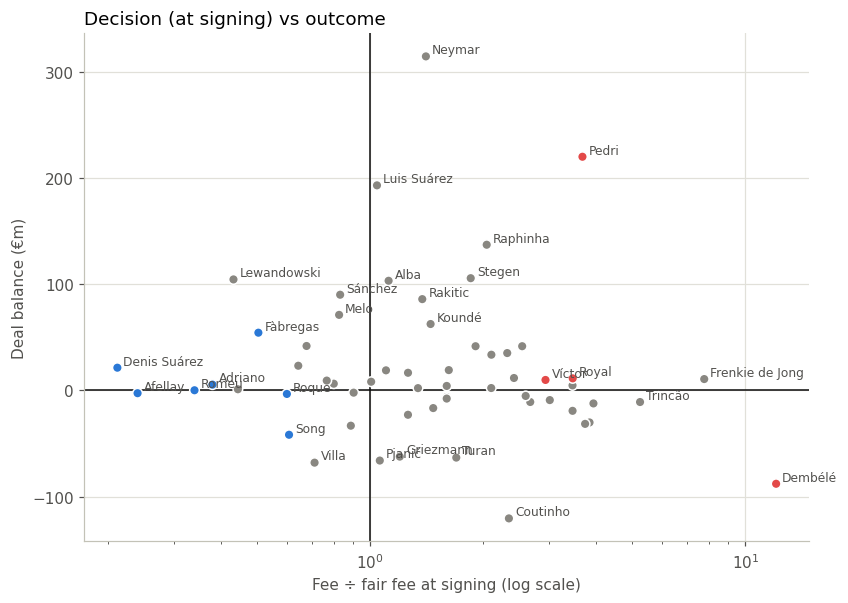

decision_outcome
Smart buy, paid off                23
Sound buy, broke even              21
Sound buy, went wrong              11
Overpaid, but it paid off           3
Overpaid, as the numbers warned     1
Name: count, dtype: int64

In [24]:
col = d.decision.map({'Overpaid': RED, 'Bargain': BLUE}).fillna(GRAY)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.scatter(d.decision_ratio, d.balance_adj.clip(-200, 350), c=col, s=40, edgecolor='white', zorder=3)
ax.axvline(1, color=INK, lw=1); ax.axhline(0, color=INK, lw=1); ax.set_xscale('log')
for _, r in d.iterrows():
    if abs(r.balance_adj) > 60 or r.decision != 'Fair price' or r.decision_ratio > 4:
        ax.annotate(short(r.player), (r.decision_ratio, min(max(r.balance_adj, -200), 350)), fontsize=8, xytext=(4, 2), textcoords='offset points', color='#52514e')
ax.set_xlabel('Fee ÷ fair fee at signing (log scale)'); ax.set_ylabel('Deal balance (€m)')
ax.set_title('Decision (at signing) vs outcome', loc='left'); plt.show()
d.decision_outcome.value_counts()

**Reading it:** only Dembélé was clearly overpaid on both views *and* turned out badly. Most of Barça's bad deals (Coutinho, Griezmann, Pjanić, Arda Turan, Vermaelen, Neto) were **defensible at the time**: the fee sat inside the normal range for the player's record and valuation. They went wrong afterwards through injuries, fit, or decline. De Jong, Trincão, Dest and André Gomes look expensive against their stats but not against their market values; stats undervalue young prospects.

## 7d. Barça vs Real Madrid vs Atlético

The same pipeline, run on every paid signing by the two Madrid clubs (football-€ basis; wages imputed). Deals missing from the dataset were filled in by hand for them too (`data/curated/missing_signings_rivals.csv`: Bale, Hazard, Özil, Mandžukić, Jackson Martínez, Diego Costa and others). Atlético's 2014/15 line-ups are missing from the dataset, so two spells from that season have no performance data and are excluded.

In [25]:
S = json.load(open('../outputs/model_summary.json'))['headline']
pd.DataFrame(S['clubs']).round(3)

,Barcelona,Real Madrid,Atlético Madrid
signings,59.000,56.000,80.000
spent_m,3043.700,2742.100,2244.700
recovered_m,1710.500,1728.800,1680.600
perf_value_m,2525.900,2635.300,2049.300
total_balance_m,1192.700,1622.000,1485.100
wages_m,2769.400,3064.900,2066.200
return_per_eur_total_cost,0.729,0.752,0.865
balance_per_eur,0.392,0.592,0.662
median_balance_m,5.500,8.000,7.600
good_share,0.441,0.536,0.562


In [26]:
pd.DataFrame(S['clubs_2013']).round(3)   # 2013/14 on: the most complete data

,Atlético Madrid,Barcelona,Real Madrid
signings,71.000,51.000,46.000
spent_m,1953.000,2535.300,2225.800
recovered_m,1352.600,1503.300,1298.000
perf_value_m,1497.400,2041.600,2156.700
total_balance_m,896.900,1009.600,1228.900
wages_m,1437.200,2024.200,2195.700
return_per_eur_total_cost,0.841,0.777,0.781
balance_per_eur,0.459,0.398,0.552
median_balance_m,5.500,4.800,8.000
good_share,0.521,0.451,0.543


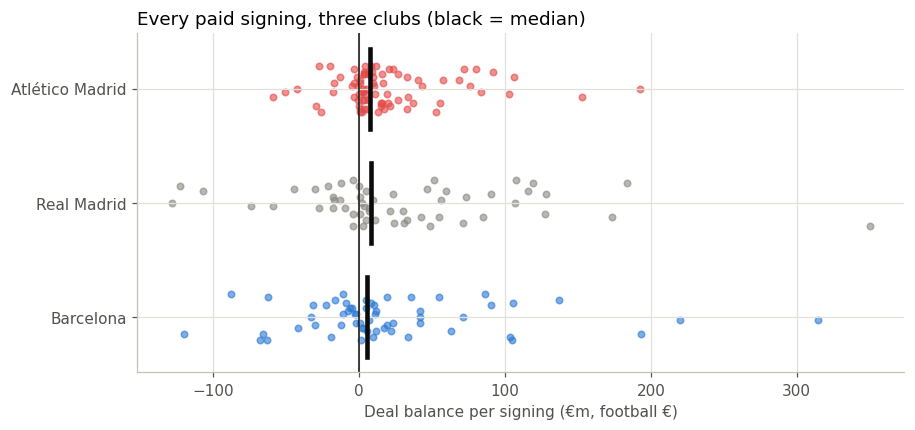

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
clubs = ['Barcelona', 'Real Madrid', 'Atlético Madrid']
for i, c in enumerate(clubs):
    x = allclubs[(allclubs.club == c) & allclubs.balance_adj.notna()]
    jit = (np.arange(len(x)) * 37 % 17 - 8) / 40
    ax.scatter(x.balance_adj.clip(-150, 350), i + jit, s=18, alpha=.6, color=[BLUE, GRAY, RED][i])
    ax.plot([x.balance_adj.median()] * 2, [i - .35, i + .35], color=INK, lw=3)
ax.set_yticks(range(3)); ax.set_yticklabels(clubs); ax.axvline(0, color=INK, lw=1)
ax.set_xlabel('Deal balance per signing (€m, football €)'); ax.set_title('Every paid signing, three clubs (black = median)', loc='left'); plt.show()

In [28]:
for c in clubs:
    x = allclubs[(allclubs.club == c) & allclubs.balance_adj.notna()].sort_values('balance_adj')
    print(c, '| worst:', ', '.join(f"{p} ({b:+.0f})" for p, b in zip(x.player.head(4), x.balance_adj.head(4))),
          '| best:', ', '.join(f"{p} ({b:+.0f})" for p, b in zip(x.player.tail(4)[::-1], x.balance_adj.tail(4)[::-1])))

Barcelona | worst: Philippe Coutinho (-120), Ousmane Dembélé (-88), David Villa (-68), Miralem Pjanić (-66) | best: Neymar (+315), Pedri (+220), Luis Suárez (+193), Raphinha (+137)
Real Madrid | worst: Gareth Bale (-128), James Rodríguez (-123), Eden Hazard (-107), Fábio Coentrão (-74) | best: Vinicius Junior (+388), Casemiro (+184), Ángel Di María (+174), Toni Kroos (+128)
Atlético Madrid | worst: Diego Costa (-59), João Félix (-51), Thomas Lemar (-42), Vitolo (-30) | best: Antoine Griezmann (+192), Jan Oblak (+153), Gabi (+106), Diego Godín (+103)


### Is there a "Barça premium"?

For €10m+ deals by the three clubs: regress log(fee ÷ fair fee) on club, signing year (and age, for the stats view), with Atlético as the reference.

In [29]:
pd.DataFrame({k: {c: v[c] for c in ('Barcelona', 'Real Madrid')} for k, v in S['premium_tests'].items()})

,vs_market_value,vs_stats_fair_fee
Barcelona,"{'premium_pct': 7.9, 'ci_pct': [-11.6, 31.8], ...","{'premium_pct': 31.8, 'ci_pct': [-2.8, 78.6], ..."
Real Madrid,"{'premium_pct': -2.6, 'ci_pct': [-20.9, 19.9],...","{'premium_pct': -8.9, 'ci_pct': [-35.9, 29.5],..."


Against players' **stats before joining**, Barça paid about **+32%** more than Atlético for a comparable record (p ≈ 0.08). Real Madrid paid no premium. Against **Transfermarkt valuations** the gap is small and not significant (+8%). Barça's fees look normal next to the market's valuations, but high next to the players' actual output, which fits a club that pays for reputation and potential.

### Wages: Capology payroll shares vs my earlier estimates

In [30]:
from src.wages import fit_wage_curve, validate
f = fit_wage_curve(scored)
print(f"Wage curve (n={int(f.nobs)} Capology salaries): within a squad, wage ∝ value^{f.params['lmv']:.2f} × e^({f.params['age']:.3f}·age)")
validate(scored)   # leave-one-season-out: estimate a Barça season's salaries without its Capology figures

Wage curve (n=117 Capology salaries): within a squad, wage ∝ value^0.64 × e^(0.184·age)


,season,n,corr_log,median_abs_pct_err
0,2017,22,0.739,40.9
1,2018,23,0.850,39.4
2,2020,19,0.751,31.4


The payroll split gets the *ranking* of salaries broadly right (log correlation 0.74 to 0.85), but individual estimates are off by 30 to 40% on a typical player. That's why actual Capology figures replace the estimate wherever they exist (Barça 2017/18, 2018/19, 2020/21), and a player's other seasons are scaled by his own actual/estimated ratio.

In [31]:
x = d[['player','seasons','wages_old_adj','wages_adj','wage_source']].copy()
print('correlation with the old hand estimates:', round(x[['wages_old_adj','wages_adj']].corr().iloc[0,1], 2))
x.assign(diff=x.wages_adj - x.wages_old_adj).sort_values('diff').round(1)

correlation with the old hand estimates: 0.87


,player,seasons,wages_old_adj,wages_adj,wage_source,diff
8,Neymar,4,188.9,78.6,Capology payroll share,-110.3
37,Frenkie de Jong,7,194.1,97.9,Capology payroll share,-96.2
10,Marc-André ter Stegen,11,189.6,120.3,Capology actual + payroll share,-69.3
6,Jordi Alba,11,193.1,130.5,Capology actual + payroll share (pre-2013 extr...,-62.6
28,Ousmane Dembélé,6,140.7,92.2,Capology actual + payroll share,-48.5
4,Alexis Sánchez,3,86.3,49.9,Capology payroll share (pre-2013 extrapolated),-36.4
48,Ferran Torres,5,66.2,36.6,Capology payroll share,-29.6
5,Cesc Fàbregas,3,120.9,94.5,Capology payroll share (pre-2013 extrapolated),-26.3
32,Clément Lenglet,4,45.7,27.7,Capology actual + payroll share,-17.9
29,Philippe Coutinho,4,119.9,103.0,Capology actual + payroll share,-16.9


## 8. Robustness: how much do the wage figures matter?

Scale every wage by 0.5× and 1.5× and re-run Test 2.

In [32]:
from src.value import club_verdicts
rows = []
for k in [0.5, 1.0, 1.5]:
    x = d.copy(); x['net_total_cost_adj'] = x.net_fee_cost_adj + k*x.wages_adj
    x = club_verdicts(x, 'net_total_cost_adj')
    rows.append(x.set_index('player')['net_total_cost_adj_verdict'].rename(f'wages ×{k}'))
sens = pd.concat(rows, axis=1)
sens[(sens != 'Fair price').any(axis=1)]

,wages ×0.5,wages ×1.0,wages ×1.5
player,,,
David Villa,Overpaid,Overpaid,Overpaid
Javier Mascherano,Overpaid,Overpaid,Overpaid
Neymar,Bargain,Bargain,Bargain
Luis Suárez,Overpaid,Overpaid,Overpaid
Samuel Umtiti,Overpaid,Overpaid,Overpaid
Ousmane Dembélé,Overpaid,Overpaid,Overpaid
Philippe Coutinho,Overpaid,Overpaid,Overpaid
Arthur Melo,Bargain,Fair price,Fair price
Antoine Griezmann,Overpaid,Overpaid,Overpaid


## 9. Limitations (read before quoting results)

* **Box-score stats miss a lot.** Build-up play, pressing and progressive passing aren't in the data, so deep midfielders (Frenkie de Jong, Pjanić) and ball-playing defenders are probably under-rated.
* **2010–12 performance is missing** (league and Europe); those seasons are credited at each player's covered average.
* **Copa del Rey and Supercopa count only through trophy points.** Cup minutes are mostly rotation and hard to benchmark as performance, but winning them earns credit.
* **Trophy weights (3 / 2 / 1 / 0.75 / 0.5) are a preference**, not estimated. The market model estimates only the euro value of one point.
* **Sell-on clauses** (a % of a player's next transfer) aren't in the data, so any extra money Barça received that way isn't counted.
* **The 5-season payback** in the deal balance is an assumption; section 5b shows how the verdicts shift with 3 or 7.
* **Decision at signing** uses at most the last two league seasons in the 14 covered leagues (Brazilian and most non-European leagues only from 2024), so players from Brazil are judged on market value alone.
* **Rivals** have imputed wages and hand-filled early deals. Atlético's 2014/15 line-ups are missing from the dataset, and the dataset lacks transfer histories for many players who retired before ~2022, which is why hand-filled tables were needed for all three clubs.
* **Positions are each player's current Transfermarkt position**, not necessarily his role at Barça.
* **Wages are partly estimated**: actual Capology salaries cover 3 Barça seasons; other seasons split the real payroll totals by value and age (typical error ±30–40% per player, see section 6). Capology's own figures are estimates too. Treat Test 2 as supporting evidence.
* **Ongoing players** (Pedri, Raphinha, Koundé, Olmo, …) are credited with their current market value as money recoverable. Their verdicts can still change.
* **Injuries count against a player.** Minutes share is part of the score, so Umtiti's or Dembélé's injury years lower their value. That's intentional: an injured signing doesn't justify his fee.
* The **market premium** (≈1.25) and the **80% interval** are choices; change them in `src/value.py` and `src/market.py`.
